# Imports and Installations

In [99]:
### IMPORT LIBRARIES
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_val_predict, train_test_split
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve, PrecisionRecallDisplay, brier_score_loss
from sklearn.calibration import CalibrationDisplay
from sklearn.utils import resample

from statsmodels.stats.contingency_tables import mcnemar

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
### CHANGE WORKING DIRECTORY
import os

# define the path to your desired folder
# change folder_path as needed
folder_path = '/content/drive/MyDrive/School/Winter 2026/BEM228 Shared/'

# change the current working directory
os.chdir(folder_path)

# check
current_directory = os.getcwd()
print(f"Current working directory: {current_directory}")

Current working directory: /content/drive/MyDrive/School/Winter 2026/BEM228 Shared


In [118]:
### LOAD DATASET
df = pd.read_csv(os.path.join(folder_path, 'allergy_data.csv'))
df

,SUBJECT_ID,BIRTH_YEAR,GENDER_FACTOR,RACE_FACTOR,ETHNICITY_FACTOR,PAYER_FACTOR,ATOPIC_MARCH_COHORT,AGE_START_YEARS,AGE_END_YEARS,SHELLFISH_ALG_START,...,CASHEW_ALG_END,ATOPIC_DERM_START,ATOPIC_DERM_END,ALLERGIC_RHINITIS_START,ALLERGIC_RHINITIS_END,ASTHMA_START,ASTHMA_END,FIRST_ASTHMARX,LAST_ASTHMARX,NUM_ASTHMARX
0,1,2006,S1 - Female,R1 - Black,E0 - Non-Hispanic,P1 - Medicaid,False,0.093087,3.164956,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,1994,S1 - Female,R0 - White,E0 - Non-Hispanic,P0 - Non-Medicaid,False,12.232717,18.880219,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.262834,18.880219,2.0
2,3,2006,S0 - Male,R0 - White,E1 - Hispanic,P0 - Non-Medicaid,True,0.010951,6.726899,NaN,...,NaN,4.884326,NaN,3.917864,6.157426,5.127995,NaN,1.404517,6.157426,4.0
3,4,2004,S0 - Male,R4 - Unknown,E1 - Hispanic,P0 - Non-Medicaid,False,2.398357,9.111567,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,2006,S1 - Female,R1 - Black,E0 - Non-Hispanic,P0 - Non-Medicaid,False,0.013689,6.193018,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
333195,333196,2006,S0 - Male,R0 - White,E0 - Non-Hispanic,P0 - Non-Medicaid,False,0.736482,7.449692,NaN,...,NaN,0.736482,NaN,NaN,NaN,5.426420,7.449692,NaN,NaN,NaN
333196,333197,2006,S1 - Female,R1 - Black,E0 - Non-Hispanic,P1 - Medicaid,True,0.019165,6.984257,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
333197,333198,2006,S0 - Male,R0 - White,E0 - Non-Hispanic,P0 - Non-Medicaid,False,0.443532,7.405886,NaN,...,NaN,NaN,NaN,NaN,NaN,2.321697,NaN,2.321697,6.650240,4.0
333198,333199,2006,S0 - Male,R3 - Other,E0 - Non-Hispanic,P0 - Non-Medicaid,True,0.013689,7.017112,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# View the Data

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 333200 entries, 0 to 333199
Data columns (total 50 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   SUBJECT_ID               333200 non-null  int64  
 1   BIRTH_YEAR               333200 non-null  int64  
 2   GENDER_FACTOR            333200 non-null  object 
 3   RACE_FACTOR              333200 non-null  object 
 4   ETHNICITY_FACTOR         333200 non-null  object 
 5   PAYER_FACTOR             333200 non-null  object 
 6   ATOPIC_MARCH_COHORT      333200 non-null  bool   
 7   AGE_START_YEARS          333200 non-null  float64
 8   AGE_END_YEARS            333200 non-null  float64
 9   SHELLFISH_ALG_START      5246 non-null    float64
 10  SHELLFISH_ALG_END        1051 non-null    float64
 11  FISH_ALG_START           1796 non-null    float64
 12  FISH_ALG_END             527 non-null     float64
 13  MILK_ALG_START           7289 non-null    float64
 14  MILK

In [119]:
### FIND NEGATIVE VALUE COUNTS PER COLUMN
int_cols = df.select_dtypes(include=[np.float64]).columns
negative_ints = df[int_cols] < 0

df_sum = (df[int_cols]<0).sum()
print(df_sum[df_sum > 1])

# drop rows with negative values
mask = (df.iloc[:, 7:] < 0).any(axis=1)
df = df.loc[~mask].reset_index(drop=True)

AGE_START_YEARS            25
MILK_ALG_START              6
MILK_ALG_END                5
SOY_ALG_START               2
SOY_ALG_END                 2
EGG_ALG_START               4
EGG_ALG_END                 3
ATOPIC_DERM_START          10
ALLERGIC_RHINITIS_START     8
dtype: int64


# Plots

19


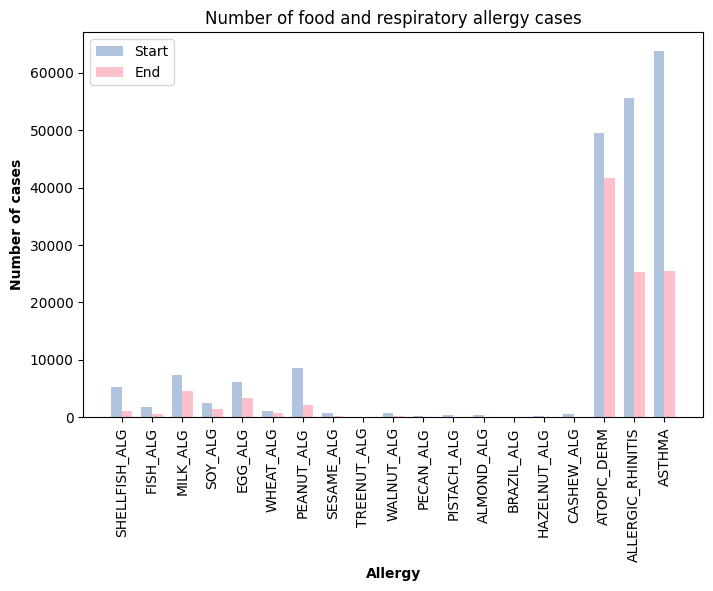

In [ ]:
### PLOT FOOD AND RESPIRATORY ALLERGY

# collect case counts
height = []
labels = []
for col in df.columns[9:-3]:
  if 'START' in col:
    labels.append(col[:-6])
  height.append(df[col].count())

bar_width = 0.35
r1 = np.arange(len(labels))  # Position of the first bar group
r2 = [x + bar_width for x in r1]  # Position of the second bar group
print(len(height[0::2]))

# create figure
fig, ax = plt.subplots(figsize=(8, 5))

# plot the bars
ax.bar(r1, height[0::2], color='lightsteelblue', width=bar_width, label='Start')
ax.bar(r2, height[1::2], color='pink', width=bar_width, label='End')


ax.set_xlabel('Allergy', fontweight='bold')
ax.set_ylabel('Number of cases', fontweight='bold')
ax.set_title('Number of food and respiratory allergy cases')
ax.set_xticks([r + bar_width / 2 for r in r1], labels, rotation=90)

ax.legend()
plt.box(True)
plt.show()

16


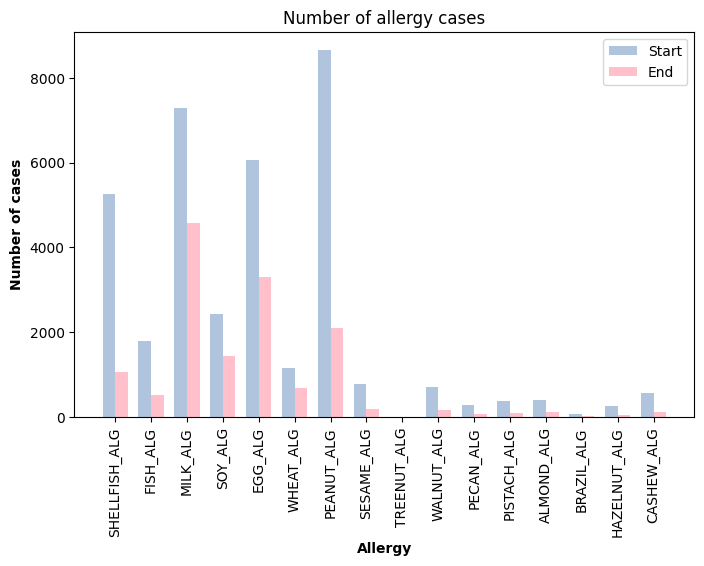

In [ ]:
### PLOT FOOD ALLERGY COUNTS

# collect case counts
height = []
labels = []

for col in df.filter(like='ALG').columns:
  if 'START' in col:
    labels.append(col[:-6])
  height.append(df[col].count())

bar_width = 0.35
r1 = np.arange(len(labels))  # Position of the first bar group
r2 = [x + bar_width for x in r1]  # Position of the second bar group
print(len(height[0::2]))

# create figure
fig, ax = plt.subplots(figsize=(8, 5))

# plot the bars
ax.bar(r1, height[0::2], color='lightsteelblue', width=bar_width, label='Start')
ax.bar(r2, height[1::2], color='pink', width=bar_width, label='End')


ax.set_xlabel('Allergy', fontweight='bold')
ax.set_ylabel('Number of cases', fontweight='bold')
ax.set_title('Number of allergy cases')
ax.set_xticks([r + bar_width / 2 for r in r1], labels, rotation=90)

ax.legend()
plt.box(True)
plt.show()

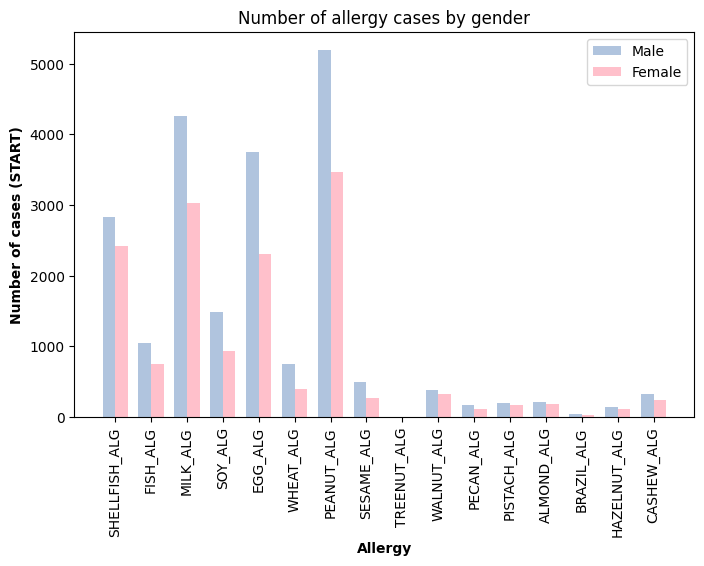

In [ ]:
### PLOT GENDER DISTRIBUTIONS FOR ALLERGY
df_female = df[df['GENDER_FACTOR'] == 'S1 - Female'].copy()
df_male = df[df['GENDER_FACTOR'] == 'S0 - Male'].copy()

# collect case counts
height_females = []
height_males = []
labels = []

for col in df_female.filter(like='ALG_START').columns:
  labels.append(col[:-6])
  height_females.append(df_female[col].count())

for col in df_male.filter(like='ALG_START').columns:
  height_males.append(df_male[col].count())

bar_width = 0.35
r1 = np.arange(len(labels))  # Position of the first bar group
r2 = [x + bar_width for x in r1]  # Position of the second bar group

# create figure
fig, ax = plt.subplots(figsize=(8, 5))

# plot the bars
ax.bar(r1, height_males, color='lightsteelblue', width=bar_width, label='Male')
ax.bar(r2, height_females, color='pink', width=bar_width, label='Female')


ax.set_xlabel('Allergy', fontweight='bold')
ax.set_ylabel('Number of cases (START)', fontweight='bold')
ax.set_title('Number of allergy cases by gender')
ax.set_xticks([r + bar_width / 2 for r in r1], labels, rotation=90)

ax.legend()
plt.box(True)
plt.show()

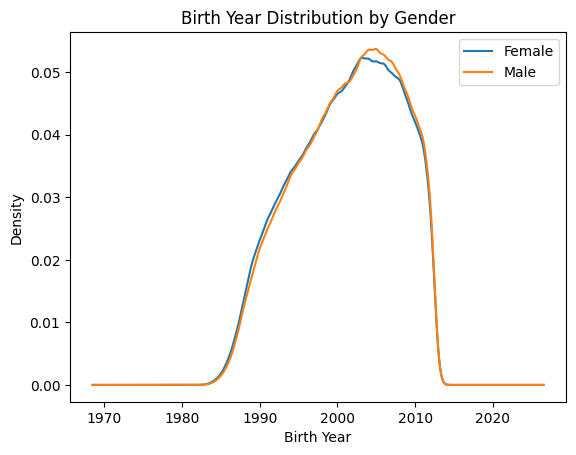

In [ ]:
# DROP ALL FOOD ALLERGIES OTHER THAN SHELLFISH, MILK, EGG, PEANUT
select_cols = ['SUBJECT_ID', 'BIRTH_YEAR', 'GENDER_FACTOR', 'RACE_FACTOR','PAYER_FACTOR', 'ATOPIC_MARCH_COHORT',
       'AGE_START_YEARS', 'AGE_END_YEARS', 'SHELLFISH_ALG_START',
       'SHELLFISH_ALG_END', 'MILK_ALG_START','MILK_ALG_END', 'EGG_ALG_START','EGG_ALG_END', 'PEANUT_ALG_START',
       'PEANUT_ALG_END', 'ATOPIC_DERM_START', 'ATOPIC_DERM_END','ALLERGIC_RHINITIS_START', 'ALLERGIC_RHINITIS_END',
       'ASTHMA_START','ASTHMA_END']
df = df[select_cols]

### PLOT BIRTH YEAR DISTRIBUTION BY GENDER
plt.figure()

df[df["GENDER_FACTOR"] == 'S1 - Female']["BIRTH_YEAR"].dropna().plot(kind="kde", label="Female")
df[df["GENDER_FACTOR"] == 'S0 - Male']["BIRTH_YEAR"].dropna().plot(kind="kde", label="Male")

plt.xlabel("Birth Year")
plt.ylabel("Density")
plt.title("Birth Year Distribution by Gender")
plt.legend()
plt.show()

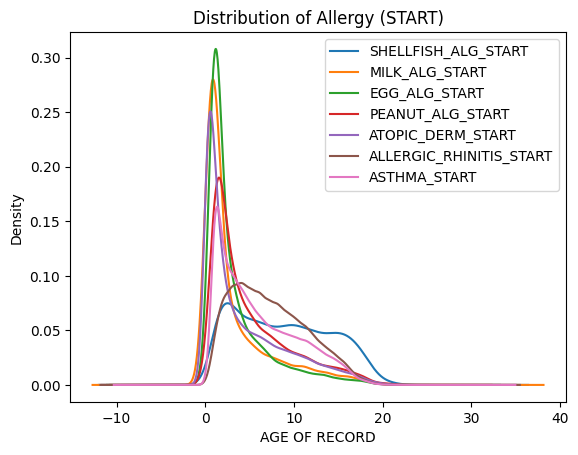

In [ ]:
### PLOT DISTRIBUTION BY ALLERGY (START)
plt.figure()

allergies = ['SHELLFISH_ALG_START','SHELLFISH_ALG_END', 'MILK_ALG_START','MILK_ALG_END', 'EGG_ALG_START','EGG_ALG_END', 'PEANUT_ALG_START',
       'PEANUT_ALG_END', 'ATOPIC_DERM_START', 'ATOPIC_DERM_END','ALLERGIC_RHINITIS_START', 'ALLERGIC_RHINITIS_END',
       'ASTHMA_START','ASTHMA_END']


for allergy in allergies:
  if 'START' in allergy:
    df[:][allergy].dropna().plot(kind="kde", label=allergy)

plt.xlabel("AGE OF RECORD")
plt.ylabel("Density")
plt.title("Distribution of Allergy (START)")
plt.legend()
plt.show()

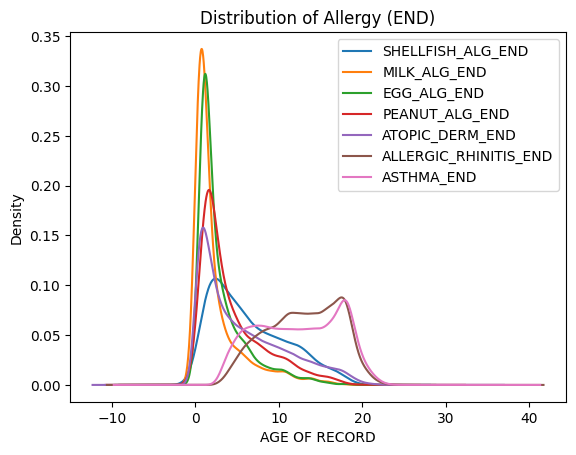

In [ ]:
### PLOT DISTRIBUTION BY ALLERGY (END)
plt.figure()

allergies = ['SHELLFISH_ALG_START','SHELLFISH_ALG_END', 'MILK_ALG_START','MILK_ALG_END', 'EGG_ALG_START','EGG_ALG_END', 'PEANUT_ALG_START',
       'PEANUT_ALG_END', 'ATOPIC_DERM_START', 'ATOPIC_DERM_END','ALLERGIC_RHINITIS_START', 'ALLERGIC_RHINITIS_END',
       'ASTHMA_START','ASTHMA_END']


for allergy in allergies:
  if 'END' in allergy:
    df[:][allergy].dropna().plot(kind="kde", label=allergy)

plt.xlabel("AGE OF RECORD")
plt.ylabel("Density")
plt.title("Distribution of Allergy (END)")
plt.legend()
plt.show()

# Preprocess the Data

In [120]:
### ENCODE THE DATA
df["GENDER_FACTOR"] = df["GENDER_FACTOR"].map({"S0 - Male": 0, "S1 - Female": 1})
df["RACE_FACTOR"] = df["RACE_FACTOR"].map({"R0 - White": 0, "R1 - Black": 1, "R2 - Asian or Pacific Islander":2, "R3 - Other": 3, "R4 - Unknown": 4})
df["PAYER_FACTOR"] = df["PAYER_FACTOR"].map({"P0 - Non-Medicaid":0, "P1 - Medicaid":1})
df["SUBJECT_ID"] = range(1, len(df) + 1)
df = df.reset_index(drop=True)

cols_to_keep = ['SUBJECT_ID', 'BIRTH_YEAR', 'GENDER_FACTOR', 'RACE_FACTOR',
       'AGE_START_YEARS', 'AGE_END_YEARS', 'SHELLFISH_ALG_START',
       'SHELLFISH_ALG_END', 'MILK_ALG_START', 'MILK_ALG_END',
       'EGG_ALG_START', 'EGG_ALG_END', 'PEANUT_ALG_START',
       'PEANUT_ALG_END', 'ATOPIC_DERM_START', 'ATOPIC_DERM_END',
       'ALLERGIC_RHINITIS_START', 'ALLERGIC_RHINITIS_END', 'ASTHMA_START','ASTHMA_END']
df = df[cols_to_keep]
df

,SUBJECT_ID,BIRTH_YEAR,GENDER_FACTOR,RACE_FACTOR,AGE_START_YEARS,AGE_END_YEARS,SHELLFISH_ALG_START,SHELLFISH_ALG_END,MILK_ALG_START,MILK_ALG_END,EGG_ALG_START,EGG_ALG_END,PEANUT_ALG_START,PEANUT_ALG_END,ATOPIC_DERM_START,ATOPIC_DERM_END,ALLERGIC_RHINITIS_START,ALLERGIC_RHINITIS_END,ASTHMA_START,ASTHMA_END
0,1,2006,1,1,0.093087,3.164956,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,1994,1,0,12.232717,18.880219,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,2006,0,0,0.010951,6.726899,NaN,NaN,1.002053,1.002053,NaN,NaN,NaN,NaN,4.884326,NaN,3.917864,6.157426,5.127995,NaN
3,4,2004,0,4,2.398357,9.111567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,2006,1,1,0.013689,6.193018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
333142,333143,2006,0,0,0.736482,7.449692,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.736482,NaN,NaN,NaN,5.426420,7.449692
333143,333144,2006,1,1,0.019165,6.984257,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
333144,333145,2006,0,0,0.443532,7.405886,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.321697,NaN
333145,333146,2006,0,3,0.013689,7.017112,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [126]:
# allergy gypes
conditions = {
    "SF": "SHELLFISH_ALG",
    "MILK": "MILK_ALG",
    "EGG": "EGG_ALG",
    "PN": "PEANUT_ALG",
    "AD": "ATOPIC_DERM",
    "AR": "ALLERGIC_RHINITIS"
}

# encode each allergy related feature
for prefix, base in conditions.items():
    start_col = f"{base}_START"
    end_col = f"{base}_END"

    # base flag for allergy
    df[prefix] = np.where(df[start_col].notna(), 1, 0)

    # allergy before age 3
    df[f"{prefix}_before3"] = np.where((df[start_col].notna()) & (df[start_col] <= 3), 1, 0)

    # allergy resolved by age 3
    df[f"{prefix}_resolvedby3"] = np.where((df[end_col].notna()) & (df[end_col] <= 3), 1, 0)

    # allergy resolved (before end of study/follow-up)
    df[f"{prefix}_resolved"] = np.where((df[end_col].notna()) & (df[end_col] < df["AGE_END_YEARS"]), 1, 0)

    # allergy persistent over 5 years duration
    duration_if_resolved = (df[end_col].notna()) & (df[end_col] - df[start_col] > 5)
    duration_if_ongoing = (df[end_col].isna()) & (df["AGE_END_YEARS"] - df[start_col] > 5)
    df[f"{prefix}_over5years"] = np.where(df[start_col].notna() & (duration_if_resolved | duration_if_ongoing), 1, 0)

    # astham started after this allergy
    df[f"ASM_after_{prefix}"] = np.where(
        (df['ASTHMA_START'].notna()) &
        (df[start_col].notna()) &
        (df['ASTHMA_START'] > df[start_col]), 1, 0
    )

# set asthma status
df["ASM"] = np.where(df["ASTHMA_START"].notna(), 1,0)

## create final dataframe
cols_to_keep = ['BIRTH_YEAR', 'GENDER_FACTOR', 'RACE_FACTOR', 'SF',
       'SF_before3', 'SF_resolvedby3', 'SF_resolved', 'SF_over5years',
       'ASM_after_SF', 'ASM', 'MILK', 'MILK_before3', 'MILK_resolvedby3',
       'MILK_resolved', 'MILK_over5years', 'ASM_after_MILK', 'EGG',
       'EGG_before3', 'EGG_resolvedby3', 'EGG_resolved', 'EGG_over5years',
       'ASM_after_EGG', 'PN', 'PN_before3', 'PN_resolvedby3', 'PN_resolved',
       'PN_over5years', 'ASM_after_PN', 'AD', 'AD_before3', 'AD_resolvedby3',
       'AD_resolved', 'AD_over5years', 'ASM_after_AD', 'AR', 'AR_before3',
       'AR_resolvedby3', 'AR_resolved', 'AR_over5years', 'ASM_after_AR']

df_final = df[cols_to_keep]
df_final

,BIRTH_YEAR,GENDER_FACTOR,RACE_FACTOR,SF,SF_before3,SF_resolvedby3,SF_resolved,SF_over5years,ASM_after_SF,ASM,...,AD_resolvedby3,AD_resolved,AD_over5years,ASM_after_AD,AR,AR_before3,AR_resolvedby3,AR_resolved,AR_over5years,ASM_after_AR
0,2006,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1994,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2006,0,0,0,0,0,0,0,0,1,...,0,0,0,1,1,0,0,1,0,1
3,2004,0,4,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2006,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
333142,2006,0,0,0,0,0,0,0,0,1,...,0,0,1,1,0,0,0,0,0,0
333143,2006,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
333144,2006,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
333145,2006,0,3,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [112]:
### SAVE FILE
df_final.to_csv("processed_data.csv", index=False)

### Load the data
df = pd.read_csv(os.path.join(folder_path, 'processed_data.csv'))

# Input Preparation

In [ ]:
# 1. Prepare your data
# Assuming 'ASM' is your target and all other columns are features
X = df.drop('ASM', axis=1)
X = X[['GENDER_FACTOR', 'RACE_FACTOR',
        'SF', 'SF_before3', 'SF_over5years', 'SF_resolved',
        'MILK', 'MILK_before3', 'MILK_over5years', 'MILK_resolved',
        'EGG', 'EGG_before3', 'EGG_over5years','EGG_resolved',
        'PN', 'PN_before3', 'PN_over5years','PN_resolved']]

# second set of features for version 2
X2 = df.drop('ASM', axis=1)
X2 = df[['SF', 'SF_before3', 'SF_resolved', 'SF_over5years',
        'MILK', 'MILK_before3', 'MILK_resolved', 'MILK_over5years',
        'EGG', 'EGG_before3', 'EGG_resolved', 'EGG_over5years',
        'PN', 'PN_before3', 'PN_resolved', 'PN_over5years',
        'AD', 'AD_before3', 'AD_resolved', 'AD_over5years',
        'AR', 'AR_before3', 'AR_resolved', 'AR_over5years']]


y = df['ASM']

# 2. Set up K-Fold Cross Validation and Scoring
kf = KFold(n_splits=5, shuffle=True, random_state=67)
scoring = ['accuracy', 'precision', 'recall', 'f1']

# Logistic Regression

Accuracy:  0.8114
Precision: 0.6325
Recall:    0.0382
F1 Score:  0.0720
ROC-AUC:   0.5165


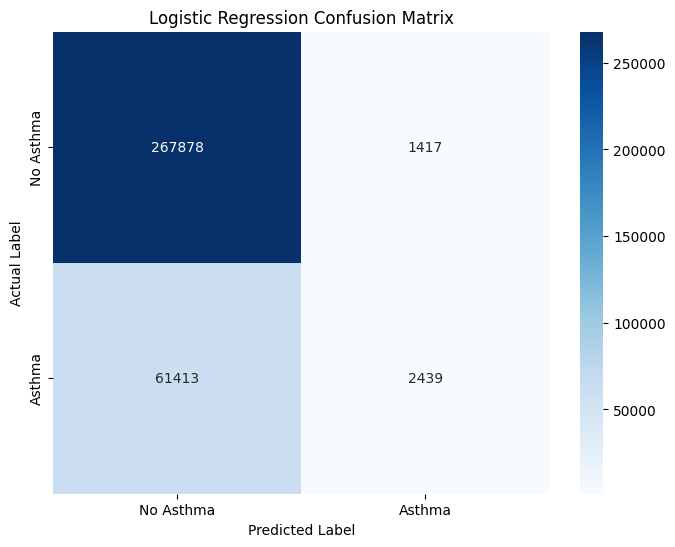

In [133]:
# logistic regression model
lr_model = LogisticRegression(max_iter=1000)
lr_y_pred = cross_val_predict(lr_model, X, y, cv=kf)

# evaluate model performance
cm_lr = confusion_matrix(y, lr_y_pred)
accuracy_lr = accuracy_score(y, lr_y_pred)
precision_lr = precision_score(y, lr_y_pred)
recall_lr = recall_score(y, lr_y_pred)
f1_lr = f1_score(y, lr_y_pred)
roc_auc_lr = roc_auc_score(y, lr_y_pred)

print(f"Accuracy:  {accuracy_lr:.4}")
print(f"Precision: {precision_lr:.4}")
print(f"Recall:    {recall_lr:.4f}")
print(f"F1 Score:  {f1_lr:.4f}")
print(f"ROC-AUC:   {roc_auc_lr:.4f}")

# Create the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Asthma', 'Asthma'],
            yticklabels=['No Asthma', 'Asthma'])

# Add labels and title
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Logistic Regression Confusion Matrix')

# Display the plot
plt.show()

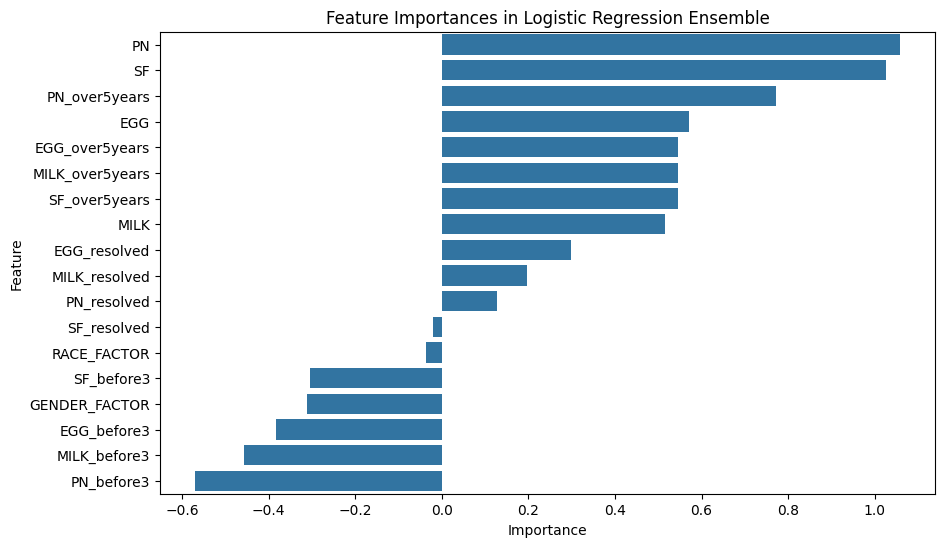

In [ ]:
# fit model
lr_model.fit(X, y)

# determine prominent features
feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': lr_model.coef_[0]})
features_df = feature_importance.sort_values(by='Importance',ascending = False)
plt.figure(figsize = (10,6))
sns.barplot(x='Importance', y = 'Feature', data = features_df)
plt.title('Feature Importances in Logistic Regression Ensemble')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

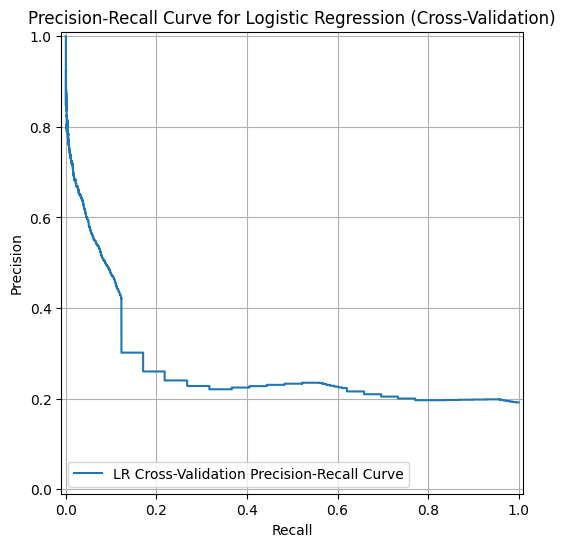

In [ ]:
# get probability predictions for the positive class using cross-validation
lr_prob = cross_val_predict(lr_model, X, y, cv=kf, method='predict_proba')[:, 1]

# calculate precision, recall, and thresholds
precision_cv, recall_cv, _ = precision_recall_curve(y, lr_prob)

# plot the Precision-Recall curve
plt.figure(figsize=(8, 6))
pr_display = PrecisionRecallDisplay(precision=precision_cv, recall=recall_cv).plot(ax=plt.gca(), name=f'LR Cross-Validation Precision-Recall Curve')
plt.title('Precision-Recall Curve for Logistic Regression (Cross-Validation)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid(True)
plt.show()

Brier Score for Logistic Regression: 0.1504


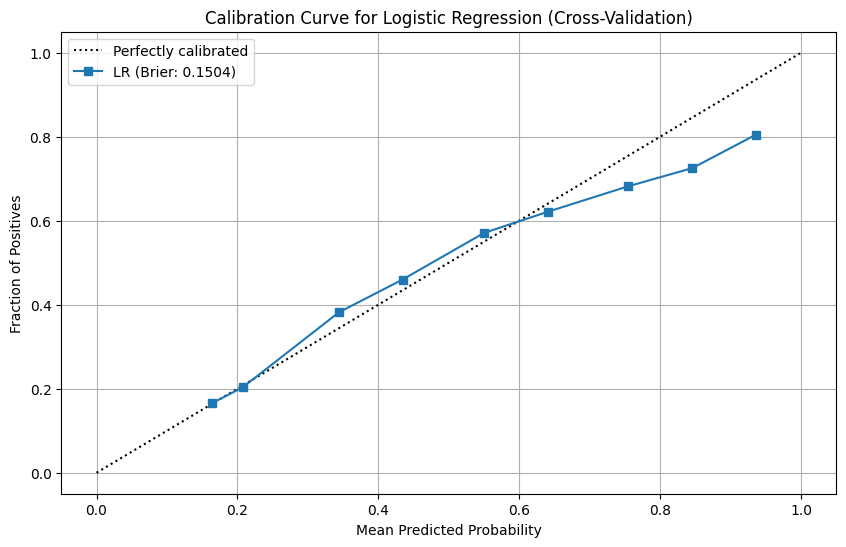

In [110]:
# Calculate Brier Score (optional, but good for calibration assessment)
bs_score_lr = brier_score_loss(y, lr_prob)
print(f"Brier Score for Logistic Regression: {bs_score_lr:.4f}")

# Plot the Calibration Curve
plt.figure(figsize=(10, 6))
CalibrationDisplay.from_predictions(y, lr_prob, n_bins=10, ax=plt.gca(), name=f'LR (Brier: {bs_score_lr:.4f})')
plt.title('Calibration Curve for Logistic Regression (Cross-Validation)')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.grid(True)
plt.legend()
plt.show()

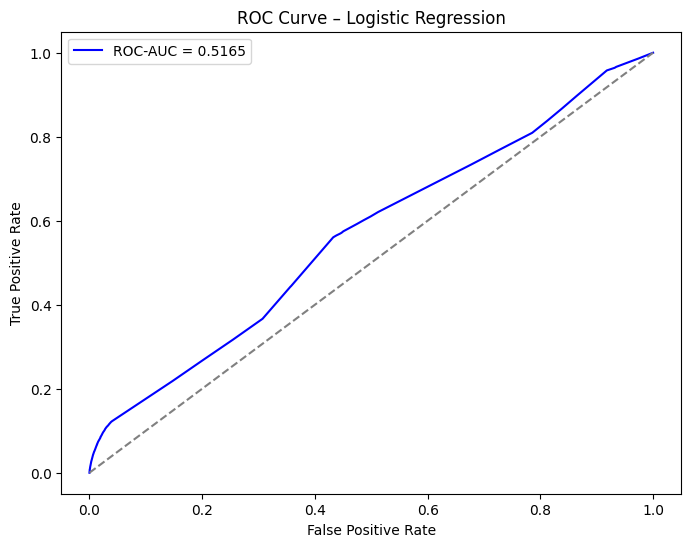

In [ ]:
fpr_lr, tpr_lr, _ = roc_curve(y, lr_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'ROC-AUC = {roc_auc_lr:.4f}', color='blue')
plt.plot([0,1],[0,1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Logistic Regression")
plt.legend()
plt.show()

# Random Forest

Accuracy:  0.6579
Precision: 0.2694
Recall:    0.4584
F1 Score:  0.3394
ROC-AUC:   0.5818


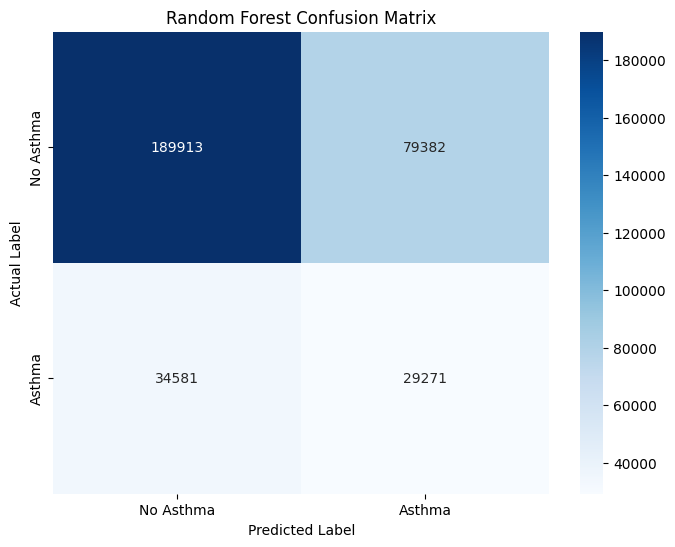

In [134]:
# random forest model
rf_model = RandomForestClassifier(n_estimators=200, random_state=67, class_weight = 'balanced' )
rf_y_pred = cross_val_predict(rf_model, X, y, cv=kf)

# evaluate model performance
cm_rf = confusion_matrix(y, rf_y_pred)
accuracy_rf = accuracy_score(y, rf_y_pred)
precision_rf = precision_score(y, rf_y_pred)
recall_rf = recall_score(y, rf_y_pred)
f1_rf = f1_score(y, rf_y_pred)
roc_auc_rf = roc_auc_score(y, rf_y_pred)

print(f"Accuracy:  {accuracy_rf:.4}")
print(f"Precision: {precision_rf:.4}")
print(f"Recall:    {recall_rf:.4f}")
print(f"F1 Score:  {f1_rf:.4f}")
print(f"ROC-AUC:   {roc_auc_rf:.4f}")

# Create the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Asthma', 'Asthma'],
            yticklabels=['No Asthma', 'Asthma'])

# Add labels and title
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Random Forest Confusion Matrix')

# Display the plot
plt.show()

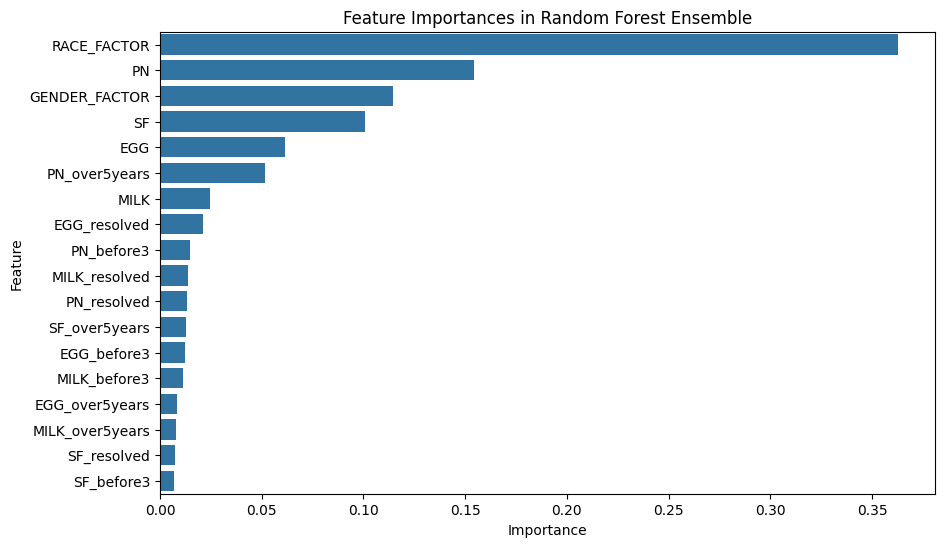

In [ ]:
# fit model
rf_model.fit(X, y)

# determine prominent features
feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': rf_model.feature_importances_})
features_df = feature_importance.sort_values(by='Importance',ascending = False)
plt.figure(figsize = (10,6))
sns.barplot(x='Importance', y = 'Feature', data = features_df)
plt.title('Feature Importances in Random Forest Ensemble')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

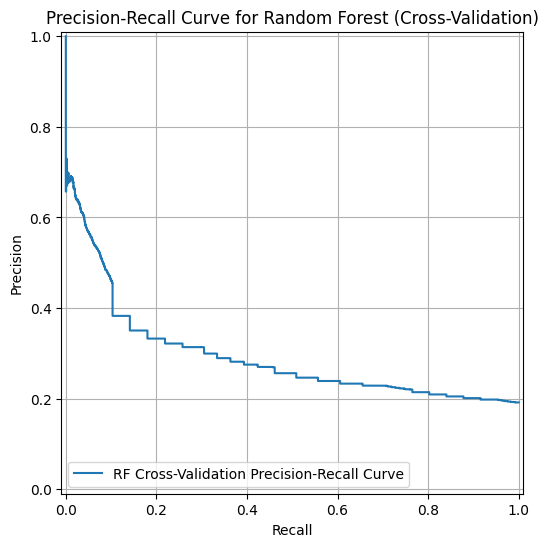

In [ ]:
# get probability predictions for the positive class using cross-validation
rf_prob = cross_val_predict(rf_model, X, y, cv=kf, method='predict_proba')[:, 1]

# calculate precision, recall, and thresholds
precision_cv, recall_cv, _ = precision_recall_curve(y, rf_prob)

# plot the Precision-Recall curve
plt.figure(figsize=(8, 6))
pr_display = PrecisionRecallDisplay(precision=precision_cv, recall=recall_cv).plot(ax=plt.gca(), name=f'RF Cross-Validation Precision-Recall Curve')
plt.title('Precision-Recall Curve for Random Forest (Cross-Validation)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid(True)
plt.show()

Brier Score for Random Forest: 0.2350


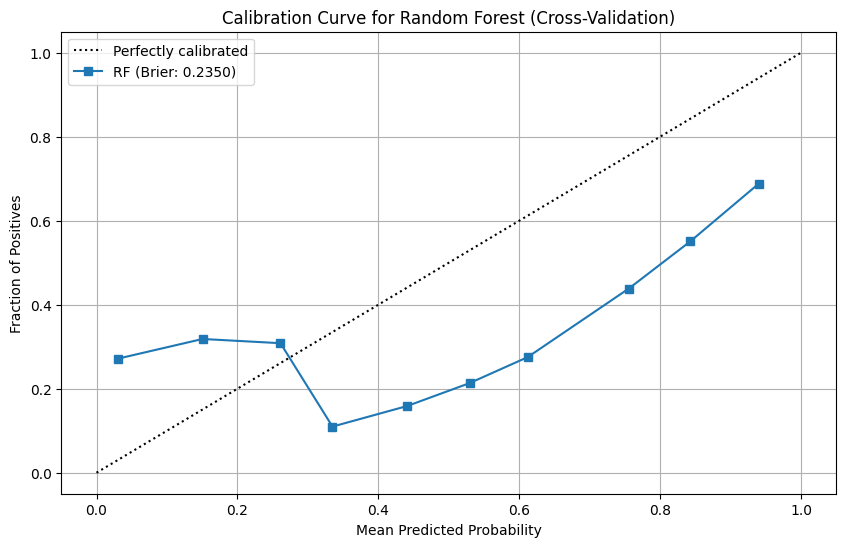

In [111]:
# Calculate Brier Score (optional, but good for calibration assessment)
bs_score_rf = brier_score_loss(y, rf_prob)
print(f"Brier Score for Random Forest: {bs_score_rf:.4f}")

# Plot the Calibration Curve
plt.figure(figsize=(10, 6))
CalibrationDisplay.from_predictions(y, rf_prob, n_bins=10, ax=plt.gca(), name=f'RF (Brier: {bs_score_rf:.4f})')
plt.title('Calibration Curve for Random Forest (Cross-Validation)')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.grid(True)
plt.legend()
plt.show()

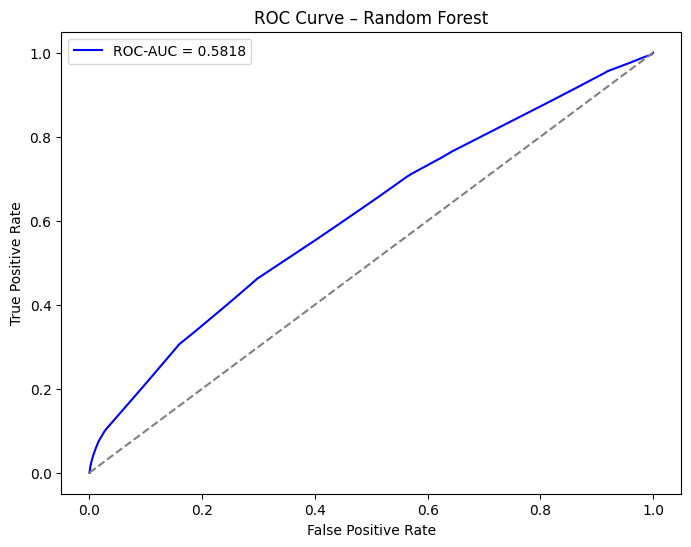

In [ ]:
fpr_rf, tpr_rf, _ = roc_curve(y, rf_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label=f'ROC-AUC = {roc_auc_rf:.4f}', color='blue')
plt.plot([0,1],[0,1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Random Forest")
plt.legend()
plt.show()

# Random Forest V2

Accuracy:  0.7732
Precision: 0.423
Recall:    0.5041
F1 Score:  0.4600
ROC-AUC:   0.6706


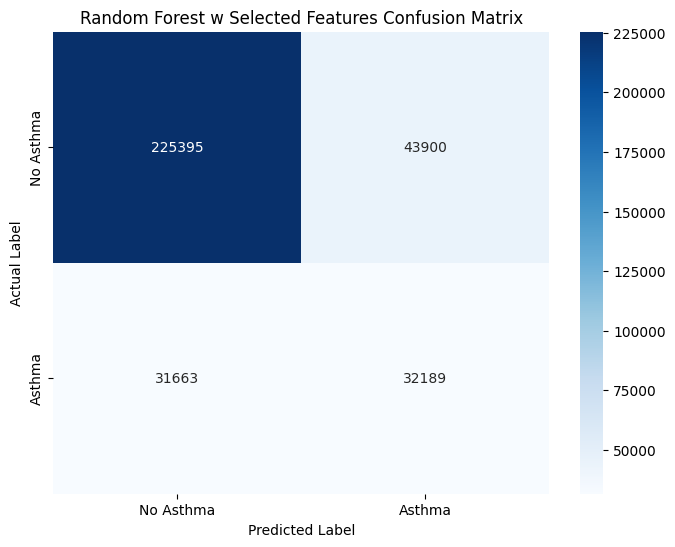

In [135]:
# random forest model
rf_model_v2 = RandomForestClassifier(n_estimators=200, random_state=67, class_weight = 'balanced' )
rf_y_pred_v2 = cross_val_predict(rf_model, X2, y, cv=kf)

# evaluate model performance
cm_rf_v2 = confusion_matrix(y, rf_y_pred_v2)
accuracy_rf_v2 = accuracy_score(y, rf_y_pred_v2)
precision_rf_v2 = precision_score(y, rf_y_pred_v2)
recall_rf_v2 = recall_score(y, rf_y_pred_v2)
f1_rf_v2 = f1_score(y, rf_y_pred_v2)
roc_auc_rf_v2 = roc_auc_score(y, rf_y_pred_v2)

print(f"Accuracy:  {accuracy_rf_v2:.4}")
print(f"Precision: {precision_rf_v2:.4}")
print(f"Recall:    {recall_rf_v2:.4f}")
print(f"F1 Score:  {f1_rf_v2:.4f}")
print(f"ROC-AUC:   {roc_auc_rf_v2:.4f}")

# Create the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf_v2, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Asthma', 'Asthma'],
            yticklabels=['No Asthma', 'Asthma'])

# Add labels and title
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Random Forest w Selected Features Confusion Matrix')

# Display the plot
plt.show()

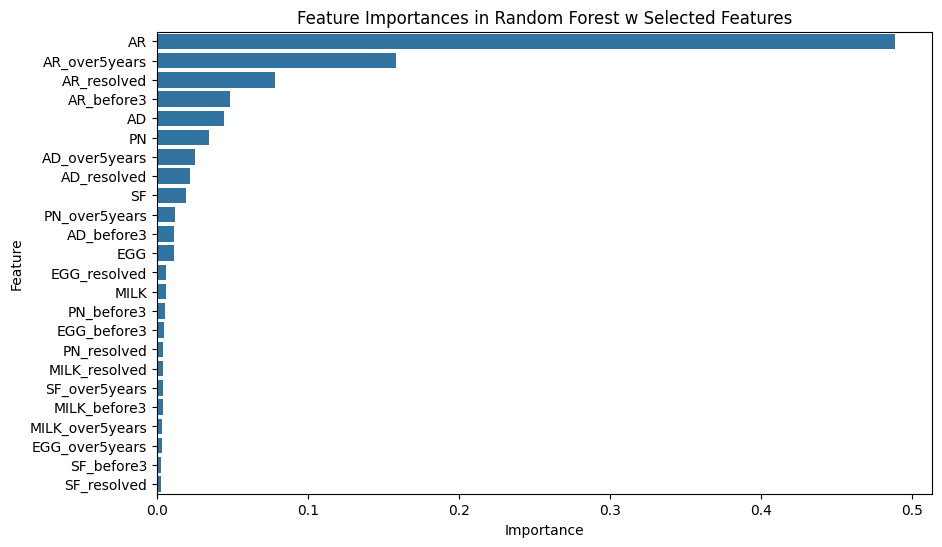

In [113]:
# fit model
rf_model_v2.fit(X2, y)

# determine prominent features
feature_importance = pd.DataFrame({'Feature': X2.columns, 'Importance': rf_model_v2.feature_importances_})
features_df = feature_importance.sort_values(by='Importance',ascending = False)
plt.figure(figsize = (10,6))
sns.barplot(x='Importance', y = 'Feature', data = features_df)
plt.title('Feature Importances in Random Forest w Selected Features')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

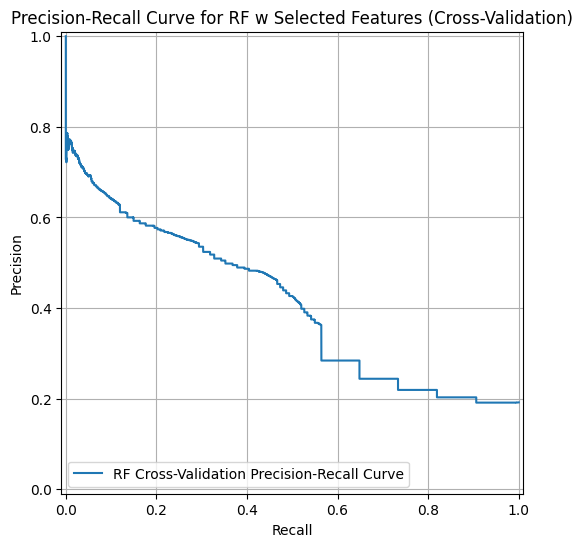

In [116]:
# get probability predictions for the positive class using cross-validation
# rf_prob_v2 = cross_val_predict(rf_model_v2, X2, y, cv=kf, method='predict_proba')[:, 1]

# calculate precision, recall, and thresholds
precision_cv, recall_cv, _ = precision_recall_curve(y, rf_prob_v2)

# plot the Precision-Recall curve
plt.figure(figsize=(8, 6))
pr_display = PrecisionRecallDisplay(precision=precision_cv, recall=recall_cv).plot(ax=plt.gca(), name=f'RF Cross-Validation Precision-Recall Curve')
plt.title('Precision-Recall Curve for RF w Selected Features (Cross-Validation)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid(True)
plt.show()

Brier Score for RF V2: 0.2029


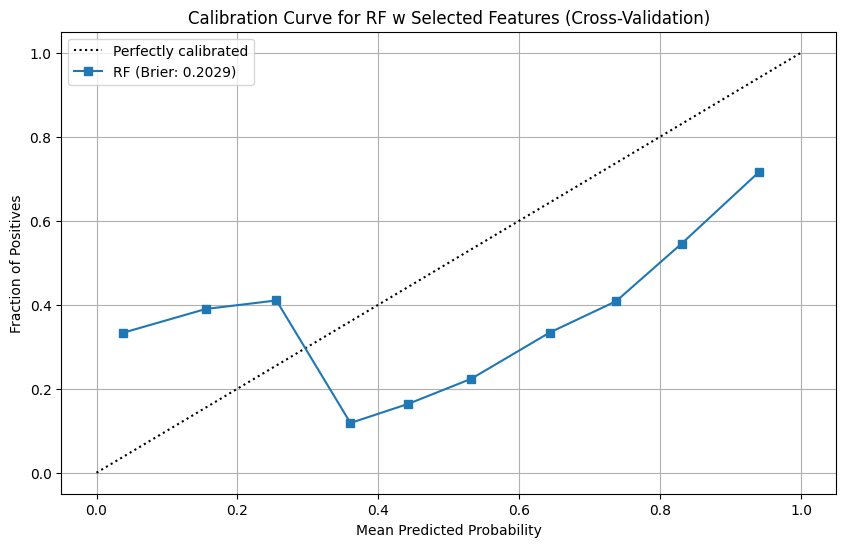

In [108]:
# Calculate Brier Score (optional, but good for calibration assessment)
bs_score_rf_v2 = brier_score_loss(y, rf_prob_v2)
print(f"Brier Score for RF V2: {bs_score_rf_v2:.4f}")

# Plot the Calibration Curve
plt.figure(figsize=(10, 6))
CalibrationDisplay.from_predictions(y, rf_prob_v2, n_bins=10, ax=plt.gca(), name=f'RF (Brier: {bs_score_rf_v2:.4f})')
plt.title('Calibration Curve for RF w Selected Features (Cross-Validation)')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.grid(True)
plt.legend()
plt.show()

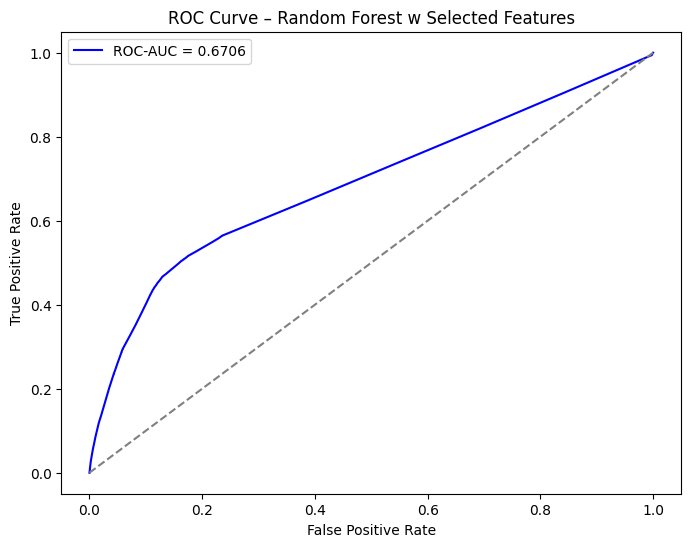

In [ ]:
fpr_rf_v2, tpr_rf_v2, _ = roc_curve(y, rf_prob_v2)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf_v2, tpr_rf_v2, label=f'ROC-AUC = {roc_auc_rf_v2:.4f}', color='blue')
plt.plot([0,1],[0,1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Random Forest w Selected Features")
plt.legend()
plt.show()

# XGBoost


Accuracy:  0.6574
Precision: 0.7367
Recall:    0.6574
F1 Score:  0.6867
ROC-AUC:   0.5841


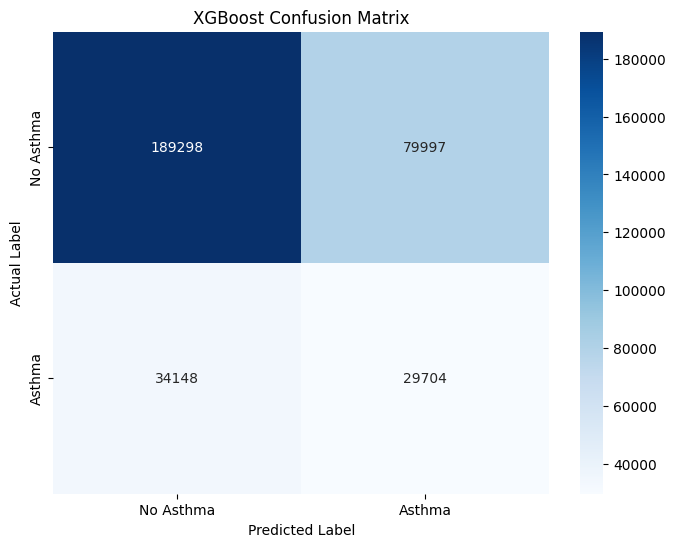

In [79]:
# calculate Scale Pos Weight for Imbalanced Data
positive = y.sum()
negative = len(y) - positive
scale_pos_weight = negative / positive
print(f"Scale_pos_weight: {scale_pos_weight:.2f}")

# xgboost model
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    min_child_weight=5,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=67
)

xgb_y_pred = cross_val_predict(xgb_model, X, y, cv=kf)

# evaluate model performance
cm_xgb = confusion_matrix(y, xgb_y_pred)
accuracy_xgb = accuracy_score(y, xgb_y_pred)
precision_xgb = precision_score(y, xgb_y_pred)
recall_xgb = recall_score(y, xgb_y_pred)
f1_xgb = f1_score(y, xgb_y_pred)
roc_auc_xgb = roc_auc_score(y, xgb_y_pred)

print(f"Accuracy:  {accuracy_xgb:.4}")
print(f"Precision: {precision_xgb:.4}")
print(f"Recall:    {recall_xgb:.4f}")
print(f"F1 Score:  {f1_xgb:.4f}")
print(f"ROC-AUC:   {roc_auc_xgb:.4f}")


# Create the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Asthma', 'Asthma'],
            yticklabels=['No Asthma', 'Asthma'])

# Add labels and title
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('XGBoost Confusion Matrix')

# Display the plot
plt.show()

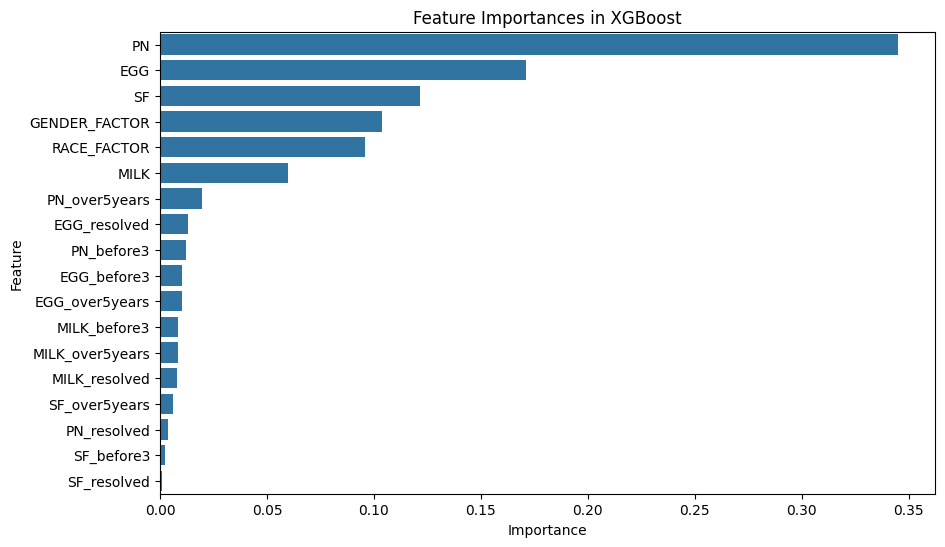

In [78]:
# fit model
xgb_model.fit(X, y)

# determine prominent features
feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': xgb_model.feature_importances_})
features_df = feature_importance.sort_values(by="Importance", ascending = False)
plt.figure(figsize = (10,6))
sns.barplot(x='Importance', y = 'Feature', data = features_df)
plt.title('Feature Importances in XGBoost')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

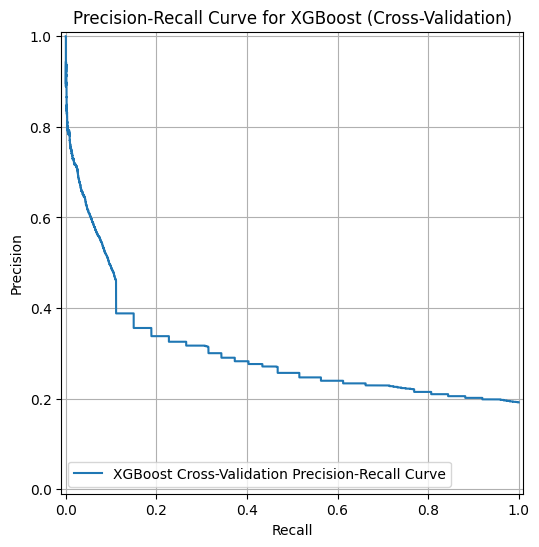

In [106]:
# get probability predictions for the positive class using cross-validation
xgb_prob = cross_val_predict(xgb_model, X, y, cv=kf, method='predict_proba')[:, 1]

# calculate precision, recall, and thresholds
precision_cv, recall_cv, _ = precision_recall_curve(y, xgb_prob)

# plot the Precision-Recall curve
plt.figure(figsize=(8, 6))
pr_display = PrecisionRecallDisplay(precision=precision_cv, recall=recall_cv).plot(ax=plt.gca(), name=f'XGBoost Cross-Validation Precision-Recall Curve')
plt.title('Precision-Recall Curve for XGBoost (Cross-Validation)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid(True)
plt.show()

Brier Score for XGBoost: 0.2355


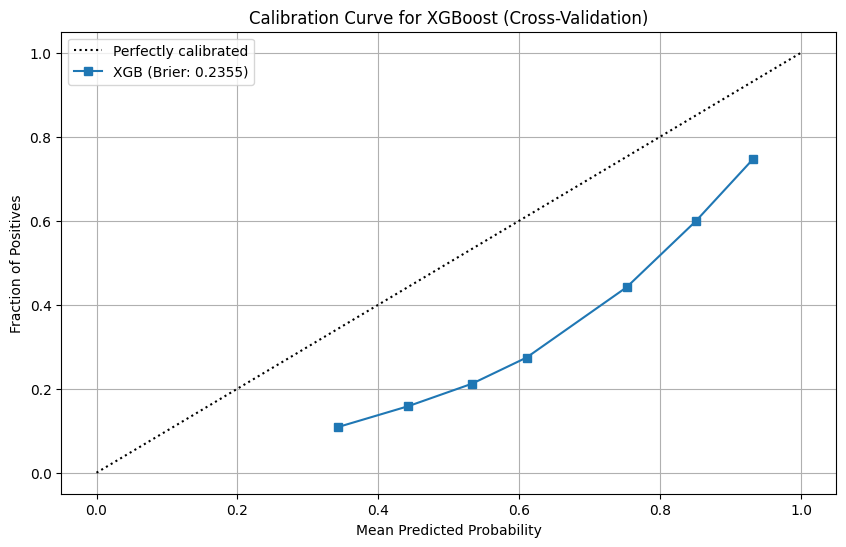

In [107]:
# Calculate Brier Score (optional, but good for calibration assessment)
bs_score_xgb = brier_score_loss(y, xgb_prob)
print(f"Brier Score for XGBoost: {bs_score_xgb:.4f}")

# Plot the Calibration Curve
plt.figure(figsize=(10, 6))
CalibrationDisplay.from_predictions(y, xgb_prob, n_bins=10, ax=plt.gca(), name=f'XGB (Brier: {bs_score_xgb:.4f})')
plt.title('Calibration Curve for XGBoost (Cross-Validation)')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.grid(True)
plt.legend()
plt.show()

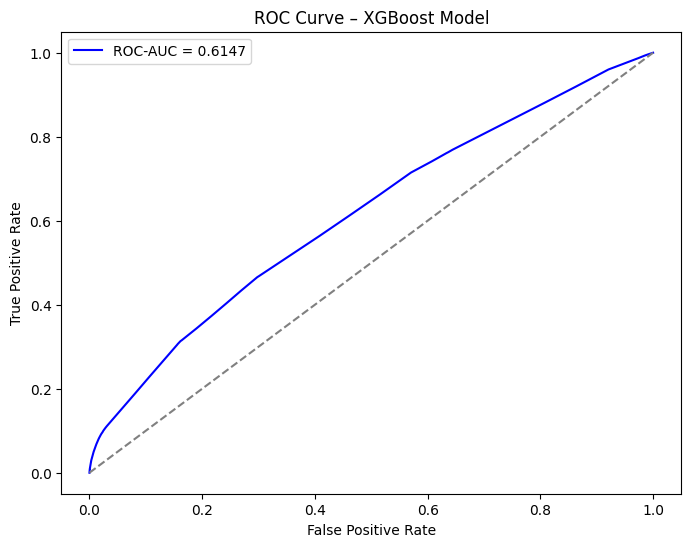

In [ ]:
fpr_xgb, tpr_xgb, _ = roc_curve(y, xgb_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, label=f'ROC-AUC = {roc_auc_xgb:.4f}', color='blue')
plt.plot([0,1],[0,1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – XGBoost Model")
plt.legend()
plt.show()

# Model Comparison and Statistical Testing

In [136]:
results = pd.DataFrame(columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC'])
results['Model'] = ['LR', 'RF', 'RF_V2', 'XGB']
results['Accuracy'] = [accuracy_lr, accuracy_rf, accuracy_rf_v2, accuracy_xgb]
results['Precision'] = [precision_lr, precision_rf, precision_rf_v2, precision_xgb]
results['Recall'] = [recall_lr, recall_rf, recall_rf_v2, recall_xgb]
results['F1'] = [f1_lr, f1_rf, f1_rf_v2, f1_xgb]
results['ROC-AUC'] = [roc_auc_lr, roc_auc_rf, roc_auc_rf_v2, roc_auc_xgb]

results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,LR,0.811405,0.632521,0.038198,0.072045,0.516468
1,RF,0.657920,0.269399,0.458419,0.339364,0.581821
2,RF_V2,0.773184,0.423044,0.504119,0.460037,0.670550
3,XGB,0.657373,0.270772,0.465201,0.342305,0.584070


In [97]:
models = ['LR', 'RF', 'RF_V2', 'XGB']
pred = [lr_y_pred, rf_y_pred, rf_y_pred_v2, xgb_y_pred]

test_stat_df = pd.DataFrame(columns=['Model 1', 'Model 2', 'Test Statistic', 'P-Value'])

ctr = 0
for i, mdl1 in enumerate(pred):
  for j, mdl2 in enumerate(pred):
    if models[i] != models[j]:
      a = np.sum((mdl1 != y) & (mdl2 != y)) # both correct
      b = np.sum((mdl1 != y) & (mdl2 == y)) # first model incorrect, second model correct
      c = np.sum((mdl1 == y) & (mdl2 != y)) # first model correct, second model incorrect
      d = np.sum((mdl1 == y) & (mdl2 == y)) # both correct

      MC_table = [[a, b],
                  [c, d]]
      MC_results = mcnemar(MC_table, exact= False)
      test_stat_df.loc[ctr, 'Model 1'] = models[i]
      test_stat_df.loc[ctr, 'Model 2'] = models[j]
      test_stat_df.loc[ctr, 'Test Statistic'] = f"{MC_results.statistic:.2f}"
      test_stat_df.loc[ctr, 'P-Value'] = MC_results.pvalue
      ctr += 1

test_stat_df

# if MC_results.pvalue < 0.05:
#     print("There is a statistically significant difference between the Logistic Regression and Random Forest 1 performances.")
# else:
#     print("There is no statistically significant difference between the two models' performances.")

,Model 1,Model 2,Test Statistic,P-Value
0,LR,RF,24781.11,0.0
1,LR,RF_V2,2216.62,0.0
2,LR,XGB,24877.19,0.0
3,RF,LR,24781.11,0.0
4,RF,RF_V2,13310.49,0.0
5,RF,XGB,11.94,0.00055
6,RF_V2,LR,2216.62,0.0
7,RF_V2,RF,13310.49,0.0
8,RF_V2,XGB,13511.86,0.0
9,XGB,LR,24877.19,0.0
